Testing the interpolation function, as the density interpolation appears incorrect.

In [11]:
import numpy as np

def interpolate_function(func, mu, x, dmu, dx, LOGSCALEX, X1LOW):

    # Find base point, and distance of (mu,x) from the base point
    if(LOGSCALEX == 1):
        x1 = np.log(x + np.exp(-X1LOW)) + X1LOW
    else:
        x1 = x


    if((np.abs(x1/dx - np.rint(x1/dx)) > 1e-10) & (np.abs(x1/dx - np.rint(x1/dx)) < 1e-4)):
        ix = int(np.rint(x1/dx))
        xs=0.0
    else:
        ix = int(np.floor(x1/dx))
        xs = x1/dx - ix

    if((ix+1) >= np.shape(func)[0]):
        ix = np.shape(func)[0]-2
        
    imu = int(np.floor(mu/dmu))
    mus = mu/dmu - imu

    f0 = func[ix,imu]
    f1 = func[ix, imu+1]
    f2 = func[ix+1, imu]
    f3 = func[ix+1,imu+1]

    value = xs*mus*f3 + xs*(1-mus)*f2 + (1-xs)*mus*f1 + (1-xs)*(1-mus)*f0

    return value

def grid_gen(xmin, xmax, mumin, mumax, nx, nmu, LOGSCALEX, DX1,X1LOW):
    # Generate polar coordinate arrays

    if(LOGSCALEX == 1):
        ii = np.linspace(0,nx-1,nx)
        x = np.exp(-X1LOW)*(np.exp(ii*DX1)-1.0)
    else:
        x = np.linspace(xmin,xmax,nx)
        
    mu = np.linspace(mumin,mumax,nmu)

    # Generate polar grid
    mu_grid, x_grid = np.meshgrid(mu, x)

    # Output
    return mu_grid, x_grid

In [49]:
from matplotlib import pyplot as plt
X1LOW = 8
XMAX = 1.e5
X1 = np.log(np.exp(X1LOW)*XMAX + 1.0)
DX1 = X1/(128 - 1.0)
dx = DX1
mugrid,xgrid = grid_gen(0,XMAX,0,1,128,128,1,DX1,8)
dmu = mugrid[0,1] - mugrid[0,0]

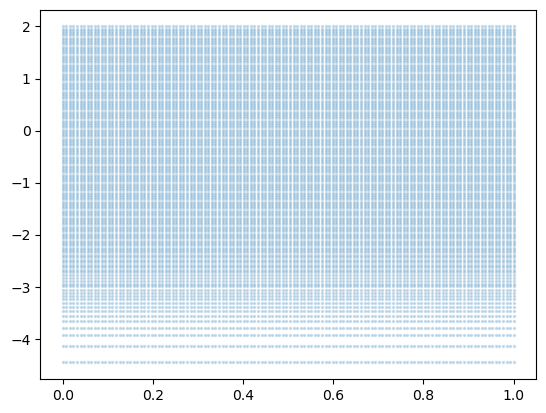

In [30]:
fig,ax = plt.subplots()
ax.scatter(mugrid[1:,:],np.log10(xgrid[1:,:]),s=2,alpha = 0.2)
plt.show()

/var/folders/72/5_kw1gh53nn015l6nm1_9csw0000gn/T/ipykernel_99118/1527551961.py:16: RuntimeWarning: divide by zero encountered in log10
  cb = ax.contourf(mugrid,np.log10(xgrid),z,levels=100)


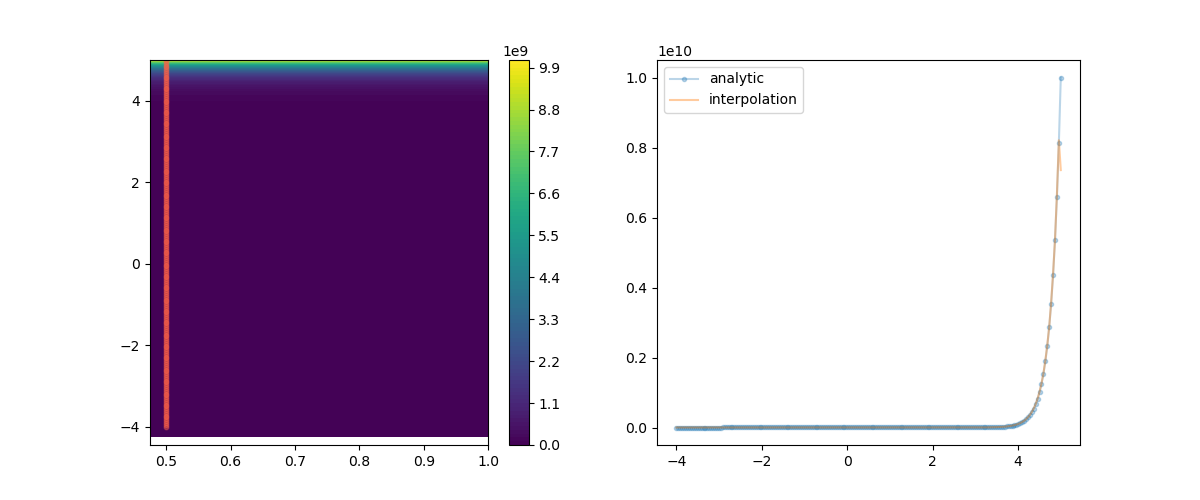

In [51]:
# let z = x**2 + mu**2
def fn_z(mugrid,xgrid):
    return xgrid**2 + mugrid**2

xcoords = np.logspace(-4,5,200)
mucoords = 0.5*np.ones_like(xcoords)

z = fn_z(mugrid,xgrid)
z_analytic = fn_z(mucoords,xcoords)

z_numerical = np.array([interpolate_function(z,mucoords[i],xcoords[i],dmu,dx,1,X1LOW) for i in range(len(mucoords))])

%matplotlib widget

fig,(ax,ax2) = plt.subplots(1,2,figsize=(12,5))
cb = ax.contourf(mugrid,np.log10(xgrid),z,levels=100)
ax.scatter(mucoords,np.log10(xcoords),c='tomato',s= 10,alpha = 0.4)
fig.colorbar(cb)
ax2.plot(np.log10(xcoords),z_analytic,'.-',alpha=0.3, label='analytic')
ax2.plot(np.log10(xcoords),z_numerical,'-',alpha = 0.4, label='interpolation')
ax2.legend()
plt.show()
